# 07 — Aspect breakdown: the "why"

**Spec: §11.** "62% satisfied" is not actionable. "62% satisfied; among the
dissatisfied, 41% mention X" is.

Step 1 of the spec says to **rebuild the lexicons from your own data** rather
than reuse the scaffold in `src/aspects.py`. The starter lexicons were written
for product/service feedback; this corpus is film reviews, so they will not
transfer — which is exactly the point of deriving them empirically.

In [1]:
import sys, json, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
from src.normalize import normalize, NORMALIZE_VERSION
from datasets import load_dataset
from src.aspects import (suggest_lexicon_terms, attribute_sentences,
                         split_sentences, save_lexicons)
from src.predict import SatisfactionModel, load_config
from src.estimate import acc_prevalence

ds = load_dataset("tblard/allocine"); ds.pop("test")
raw_va = ds["validation"]["review"]
yva = np.array(ds["validation"]["label"])

cfg = load_config(REPO / "inference_config.json")
model = SatisfactionModel(cfg)

C:\Users\Windownet\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Frequent content words in NEGATIVE reviews -- the vocabulary of complaints
# is what aspects need to cover.
neg = [raw_va[i] for i in np.flatnonzero(yva == 0)[:8000]]
top = suggest_lexicon_terms(neg, top_k=70, min_length=5)
for i in range(0, 70, 7):
    print("  ".join(f"{w}({n})" for w, n in top[i:i+7]))

scénario(1732)  histoire(1595)  acteurs(1508)  vraiment(1239)  scène(962)  mauvais(918)  personnages(911)
assez(834)  scènes(829)  reste(807)  films(748)  grand(745)  quelques(722)  temps(720)
cinéma(703)  intérêt(699)  chose(693)  beaucoup(688)  surtout(650)  après(647)  réalisateur(635)
aurait(619)  genre(614)  jamais(612)  plutôt(611)  dialogues(606)  comédie(579)  mieux(577)
premier(532)  autres(529)  dommage(528)  avait(517)  passe(513)  manque(512)  toujours(510)
final(508)  pourtant(503)  début(487)  malgré(485)  navet(460)  tellement(459)  bonne(451)
personnage(449)  aucune(440)  comment(439)  acteur(433)  effets(428)  humour(426)  autant(422)
minutes(421)  petit(418)  ridicule(411)  point(407)  action(406)  monde(406)  regarder(403)
réalisation(401)  casting(400)  moment(395)  avant(390)  suite(388)  clichés(377)  ennuyeux(375)
celui(374)  ailleurs(367)  intrigue(358)  drôle(352)  niveau(350)  totalement(350)  sujet(350)


## Lexicons derived from the output above

Grouped by hand — the grouping is a judgement call, not something to automate.
These are film-review aspects because that is what the corpus is. For a real
deployment on product feedback you would rerun the cell above on *that* corpus
and regroup.

In [3]:
FILM_ASPECTS = {
    "scénario":     {"scenario", "scénario", "histoire", "intrigue", "récit",
                     "recit", "script", "fin", "début", "debut"},
    "jeu_acteurs":  {"acteurs", "acteur", "actrice", "actrices", "jeu",
                     "interprétation", "interpretation", "casting", "rôle",
                     "role", "personnages", "personnage"},
    "réalisation":  {"réalisation", "realisation", "réalisateur", "realisateur",
                     "mise", "scène", "scene", "caméra", "camera", "plans",
                     "montage", "rythme"},
    "image_son":    {"images", "image", "musique", "bande", "son", "effets",
                     "spéciaux", "speciaux", "décors", "decors", "photographie"},
    "émotion":      {"émotion", "emotion", "émouvant", "emouvant", "ennui",
                     "ennuyeux", "touchant", "drôle", "drole", "rire", "peur"},
    "originalité":  {"original", "originale", "originalité", "originalite",
                     "cliché", "cliche", "déjà", "deja", "classique", "banal"},
}
# Persist them: the demo must use the SAME lexicons as this analysis,
# otherwise app.py silently falls back to the generic starter set and the
# published aspect table stops describing what is served.
save_lexicons(FILM_ASPECTS)
for a, terms in FILM_ASPECTS.items():
    print(f"{a:<14} {len(terms)} termes")
print("\nsaved data/aspect_lexicons.json")

scénario       10 termes
jeu_acteurs    12 termes
réalisation    12 termes
image_son      11 termes
émotion        11 termes
originalité    10 termes

saved data/aspect_lexicons.json


In [4]:
# Sentence-level attribution: score the SENTENCE, not the whole review.
# This is what makes mixed reviews work -- "le jeu est super mais le scenario
# est creux" yields positive-acting and negative-plot, not one muddled label.
sample = raw_va[:4000]
buckets = {a: [] for a in FILM_ASPECTS}
n_sent = n_attr = 0
for text in sample:
    for sent, asp in attribute_sentences(text, FILM_ASPECTS):
        n_sent += 1
        if asp:
            n_attr += 1
        for a in asp:
            buckets[a].append(sent)

print(f"{n_sent:,} sentences, {n_attr:,} carry an aspect term "
      f"({n_attr/n_sent:.1%})")
print(f"-> {1 - n_attr/n_sent:.1%} UNATTRIBUTED. Report this: a complaint with "
      f"no lexicon term is invisible to the method.")

19,430 sentences, 7,794 carry an aspect term (40.1%)
-> 59.9% UNATTRIBUTED. Report this: a complaint with no lexicon term is invisible to the method.


In [5]:
rows = []
for aspect, sents in buckets.items():
    if len(sents) < 30:
        continue
    preds = [p for p in model.predict(sents, batch_size=512) if p.confident]
    if not preds:
        continue
    raw_rate = np.mean([p.label == "positif" for p in preds])
    rows.append({"aspect": aspect, "phrases": len(sents),
                 "jugées": len(preds),
                 "brut": round(float(raw_rate), 4),
                 "corrigé": round(acc_prevalence(float(raw_rate), cfg.tpr,
                                                 cfg.fpr), 4)})
rows.sort(key=lambda r: r["corrigé"])

print(f"{'aspect':<14} {'phrases':>8} {'brut':>8} {'corrigé':>9}")
for r in rows:
    print(f"{r['aspect']:<14} {r['phrases']:>8,} {r['brut']:>8.1%} "
          f"{r['corrigé']:>9.1%}")

aspect          phrases     brut   corrigé
scénario          2,511    36.8%     35.4%
originalité         755    38.2%     36.9%
réalisation       1,652    41.3%     40.2%
émotion             946    42.2%     41.2%
image_son         2,316    51.4%     51.3%
jeu_acteurs       2,550    51.5%     51.3%


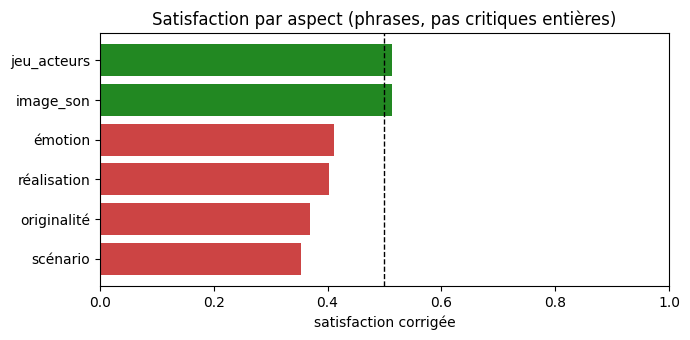

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
names = [r["aspect"] for r in rows]
ax.barh(names, [r["corrigé"] for r in rows],
        color=["#c44" if r["corrigé"] < .5 else "#282" for r in rows])
ax.axvline(.5, color="k", ls="--", lw=1)
ax.set_xlabel("satisfaction corrigée"); ax.set_xlim(0, 1)
ax.set_title("Satisfaction par aspect (phrases, pas critiques entières)")
plt.tight_layout(); plt.savefig(REPO / "data" / "fig_aspects.png", dpi=120)
plt.show()

json.dump({"unattributed_rate": round(1 - n_attr/n_sent, 4), "aspects": rows},
          open(REPO / "data" / "results_aspects.json", "w"),
          indent=2, ensure_ascii=False)

## Limitations — put these in the model card verbatim

* **No implicit aspects.** The unattributed share printed above is invisible to
  this method entirely.
* **No aspect–opinion dependency parsing.** A sentence mentioning two aspects
  is attributed to both, with the same sentiment.
* **Lexicons are hand-built and corpus-specific.** These are film-review
  aspects. Deploying on product feedback means rebuilding them from that
  corpus, not translating these.

Being precise about what the method does *not* do is what makes it credible
rather than oversold.